In [31]:
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from collections import Counter
from etc import Hamiltonian
import random

In [2]:
# Get the notebook's directory and go up to project root
notebook_dir = Path().resolve()
project_root = notebook_dir.parent
gml_path = project_root / "data" / "resources" / "generated" / "modified_graph.gml"

In [3]:
G = nx.read_gml(gml_path)

In [4]:
average_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print("Average degree:", average_degree)

Average degree: 4.477777777777778


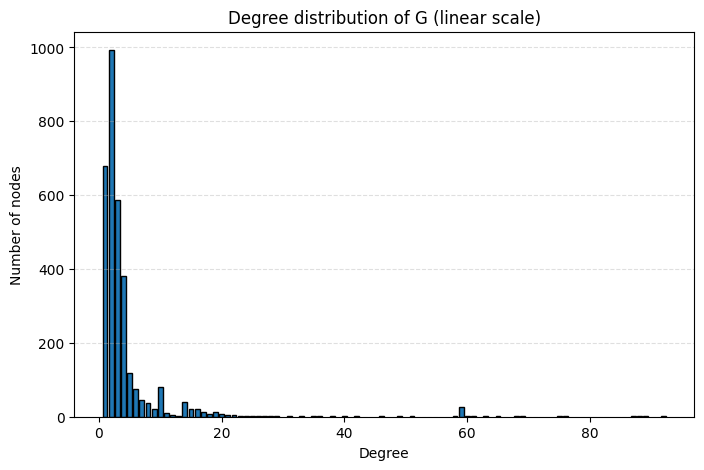

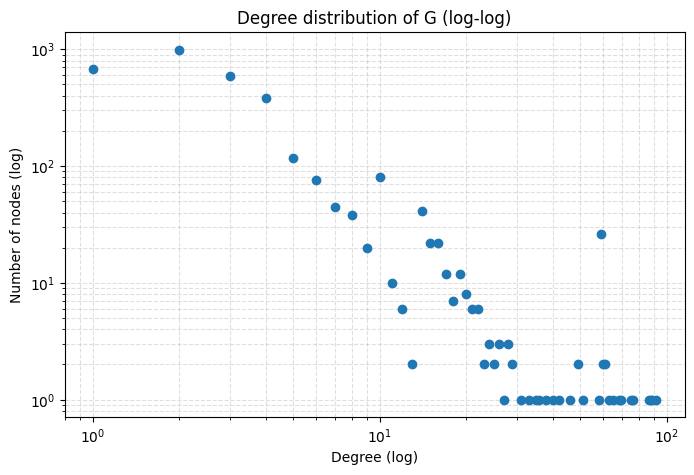

In [9]:
degrees = [d for n, d in G.degree()]
deg_counts = Counter(degrees)
deg, counts = zip(*sorted(deg_counts.items()))

# Linear-scale bar plot
plt.figure(figsize=(8,5))
plt.bar(deg, counts, width=0.8, color='C0', edgecolor='k')
plt.xlabel('Degree')
plt.ylabel('Number of nodes')
plt.title('Degree distribution of G (linear scale)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# Log-log plot for heavy-tailed distributions
plt.figure(figsize=(8,5))
plt.loglog(deg, counts, marker='o', linestyle='none')
plt.xlabel('Degree (log)')
plt.ylabel('Number of nodes (log)')
plt.title('Degree distribution of G (log-log)')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.show()

In [17]:
D = np.load(f"{project_root}/data/resources/generated/dist_matrix.npy")

In [18]:
H = Hamiltonian(G=G, distance_matrix=D)

In [22]:
mu=H.mu_density_aware(G)

In [21]:
gamma= H.gamma_balancer(mu=0.9)

In [26]:
len(G.nodes())

3240

In [27]:
nodes = list(G.nodes())

In [32]:
nodes[1]

'MAM00646c'

In [57]:
random_indices_100 = random.sample(range(len(nodes)),100)

In [60]:
h = []
for m in range(10000):
    random_indices_100 = random.sample(range(len(nodes)),100)
    h.append(H.compute(random_indices_100,mu=mu, gamma=gamma)[0])